In [1]:
# ============================================================================
# PART 1: SETUP AND PATH VERIFICATION
# ============================================================================
# Dataset 2: B-line Detection Dataset - CORRECTED FOR YOUR STRUCTURE
# Your structure: train/ (images) + train/labels/ (YOLO .txt files)
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
import random
from skimage.measure import shannon_entropy
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("talk", font_scale=1.2)

# Configure plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 12

print("="*80)
print("PART 1: SETUP AND PATH VERIFICATION")
print("="*80)

# ============================================================================
# CONFIGURATION - UPDATE THIS PATH TO YOUR DATASET LOCATION
# ============================================================================

DATASET2_PATH = r"C:\Users\Administrator\Documents\LUS-BALD"  # <-- YOUR PATH
OUTPUT_DIR = "./eda_results_dataset2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\n📁 Dataset Path: {DATASET2_PATH}")
print(f"📁 Output Directory: {OUTPUT_DIR}")

# Check if path exists
if not os.path.exists(DATASET2_PATH):
    print(f"\n❌ ERROR: Path does not exist!")
    print(f"Please verify the path: {DATASET2_PATH}")
else:
    print(f"\n✅ Path exists!")

# ============================================================================
# DISCOVER DATASET STRUCTURE
# ============================================================================

print("\n" + "="*80)
print("DISCOVERING DATASET STRUCTURE")
print("="*80)

data_path = Path(DATASET2_PATH)

# List all items in root directory
print("\n📋 Root directory contents:")
for item in data_path.iterdir():
    if item.is_dir():
        print(f"  📁 {item.name}/")
    else:
        size_kb = item.stat().st_size / 1024
        print(f"  📄 {item.name} ({size_kb:.1f} KB)")

# Look for train folder
train_path = data_path / 'train'
if train_path.exists():
    print(f"\n✅ Found train folder: {train_path}")
    
    # List contents of train folder
    print(f"\n📋 Train folder contents:")
    for item in train_path.iterdir():
        if item.is_dir():
            print(f"  📁 {item.name}/")
        else:
            size_kb = item.stat().st_size / 1024
            print(f"  📄 {item.name} ({size_kb:.1f} KB)")
    
    # Check for labels subfolder
    labels_path = train_path / 'labels'
    if labels_path.exists():
        print(f"\n✅ Found labels subfolder: {labels_path}")
        
        # Count label files
        label_files = list(labels_path.glob('*.txt'))
        print(f"   📄 Found {len(label_files)} .txt label files")
        
        # Show sample label files
        if len(label_files) > 0:
            print(f"\n   Sample label files (first 5):")
            for i, lbl in enumerate(sorted(label_files)[:5]):
                size_kb = lbl.stat().st_size / 1024
                print(f"     {i+1}. {lbl.name} ({size_kb:.2f} KB)")
    else:
        print(f"\n❌ No labels subfolder found in train folder")
else:
    print(f"\n❌ No train folder found at {train_path}")
    # Try looking for other possible structures
    possible_folders = ['images', 'data', 'dataset']
    for folder in possible_folders:
        test_path = data_path / folder
        if test_path.exists():
            print(f"\n📁 Found alternative folder: {test_path}")

PART 1: SETUP AND PATH VERIFICATION

📁 Dataset Path: C:\Users\Administrator\Documents\LUS-BALD
📁 Output Directory: ./eda_results_dataset2

✅ Path exists!

DISCOVERING DATASET STRUCTURE

📋 Root directory contents:
  📁 test/
  📁 train/
  📁 val/

✅ Found train folder: C:\Users\Administrator\Documents\LUS-BALD\train

📋 Train folder contents:
  📁 images/
  📁 labels/

✅ Found labels subfolder: C:\Users\Administrator\Documents\LUS-BALD\train\labels
   📄 Found 256 .txt label files

   Sample label files (first 5):
     1. cc6f426d-9710-4844-ad00-1e3bde984233-20_48_13.txt (0.07 KB)
     2. d8637b3c-ed73-4ad3-b08d-8ceb4724d184-23_24_10.txt (0.07 KB)
     3. ededb54a-e2fa-4d8d-9d32-9dbf5877f3a1-13_3_50.txt (0.22 KB)
     4. image_12882742373921-13_57_16.txt (0.07 KB)
     5. image_14044247853989-9_39_48.txt (0.15 KB)


In [2]:
# ============================================================================
# PART 2: LOAD IMAGES AND MATCH WITH LABELS
# ============================================================================

print("\n" + "="*80)
print("PART 2: LOADING IMAGES AND MATCHING WITH LABELS")
print("="*80)

# Define paths
train_path = data_path / 'train'
labels_path = train_path / 'labels'

# ============================================================================
# 2.1: Find all images in train folder
# ============================================================================

print("\n--- 2.1: Finding images ---")

image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
image_files = []
for ext in image_extensions:
    image_files.extend(list(train_path.glob(ext)))

# Also check if images are in a subfolder
if len(image_files) == 0:
    img_subfolder = train_path / 'images'
    if img_subfolder.exists():
        for ext in image_extensions:
            image_files.extend(list(img_subfolder.glob(ext)))

print(f"\n📸 Total images found: {len(image_files)}")

if len(image_files) > 0:
    print(f"\n   Sample images (first 5):")
    for i, img_path in enumerate(sorted(image_files)[:5]):
        size_kb = img_path.stat().st_size / 1024
        print(f"     {i+1}. {img_path.name} ({size_kb:.1f} KB)")

# ============================================================================
# 2.2: Find all label files
# ============================================================================

print("\n--- 2.2: Finding label files ---")

if labels_path.exists():
    label_files = list(labels_path.glob('*.txt'))
    print(f"\n📄 Total label files found: {len(label_files)}")
    
    if len(label_files) > 0:
        print(f"\n   Sample label files (first 5):")
        for i, lbl_path in enumerate(sorted(label_files)[:5]):
            size_kb = lbl_path.stat().st_size / 1024
            print(f"     {i+1}. {lbl_path.name} ({size_kb:.2f} KB)")
else:
    print(f"\n❌ Labels path does not exist: {labels_path}")
    label_files = []

# ============================================================================
# 2.3: Match images with their corresponding label files
# ============================================================================

print("\n--- 2.3: Matching images with labels ---")

matched_images = []
unmatched_images = []
annotations_data = []

for img_file in image_files:
    stem = img_file.stem  # filename without extension
    corresponding_label = labels_path / f"{stem}.txt"
    
    if corresponding_label.exists():
        matched_images.append({
            'image': img_file.name,
            'image_path': str(img_file),
            'label_file': corresponding_label.name,
            'label_path': str(corresponding_label)
        })
    else:
        unmatched_images.append(img_file.name)

print(f"\n✅ Images with matching labels: {len(matched_images)}")
print(f"⚠️ Images without labels: {len(unmatched_images)}")

if unmatched_images:
    print(f"\n   First 5 unmatched images:")
    for i, img_name in enumerate(unmatched_images[:5]):
        print(f"     {i+1}. {img_name}")

# ============================================================================
# 2.4: Parse YOLO format label files
# ============================================================================

print("\n--- 2.4: Parsing YOLO format label files ---")

for match in matched_images:
    label_path = match['label_path']
    img_name = match['image']
    
    try:
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        for line_num, line in enumerate(lines):
            line = line.strip()
            if line and not line.startswith('#'):  # Skip empty lines and comments
                parts = line.split()
                if len(parts) >= 9:  # YOLO polygon: class_id x1 y1 x2 y2 x3 y3 x4 y4
                    class_id = int(parts[0])
                    coords = [float(x) for x in parts[1:9]]
                    
                    annotations_data.append({
                        'image_file': img_name,
                        'label_file': Path(label_path).name,
                        'class_id': class_id,
                        'x1': coords[0],
                        'y1': coords[1],
                        'x2': coords[2],
                        'y2': coords[3],
                        'x3': coords[4],
                        'y3': coords[5],
                        'x4': coords[6],
                        'y4': coords[7],
                        'num_points': 4
                    })
    except Exception as e:
        print(f"   ⚠️ Error reading {Path(label_path).name}: {e}")

print(f"\n✅ Parsed {len(annotations_data)} B-line annotations from {len(matched_images)} images")

# ============================================================================
# 2.5: Create DataFrame
# ============================================================================

print("\n--- 2.5: Creating annotations DataFrame ---")

if annotations_data:
    df = pd.DataFrame(annotations_data)
    print(f"\n📊 Annotations DataFrame shape: {df.shape}")
    print(f"\n📋 Columns: {list(df.columns)}")
    print(f"\n👁️ First 5 annotations:")
    print(df.head())
    
    # Data types
    print(f"\n📊 Data types:")
    print(df.dtypes)
else:
    print("\n❌ No annotations were parsed")
    df = None


PART 2: LOADING IMAGES AND MATCHING WITH LABELS

--- 2.1: Finding images ---

📸 Total images found: 512

   Sample images (first 5):
     1. cc6f426d-9710-4844-ad00-1e3bde984233-20_48_13.png (203.8 KB)
     2. cc6f426d-9710-4844-ad00-1e3bde984233-20_48_13.png (203.8 KB)
     3. d8637b3c-ed73-4ad3-b08d-8ceb4724d184-23_24_10.jpeg (78.2 KB)
     4. d8637b3c-ed73-4ad3-b08d-8ceb4724d184-23_24_10.jpeg (78.2 KB)
     5. ededb54a-e2fa-4d8d-9d32-9dbf5877f3a1-13_3_50.png (238.5 KB)

--- 2.2: Finding label files ---

📄 Total label files found: 256

   Sample label files (first 5):
     1. cc6f426d-9710-4844-ad00-1e3bde984233-20_48_13.txt (0.07 KB)
     2. d8637b3c-ed73-4ad3-b08d-8ceb4724d184-23_24_10.txt (0.07 KB)
     3. ededb54a-e2fa-4d8d-9d32-9dbf5877f3a1-13_3_50.txt (0.22 KB)
     4. image_12882742373921-13_57_16.txt (0.07 KB)
     5. image_14044247853989-9_39_48.txt (0.15 KB)

--- 2.3: Matching images with labels ---

✅ Images with matching labels: 512
⚠️ Images without labels: 0

--- 2.4: 

In [3]:
# ============================================================================
# PART 3: ANNOTATION STATISTICS
# ============================================================================

print("\n" + "="*80)
print("PART 3: ANNOTATION STATISTICS")
print("="*80)

if df is None:
    print("❌ No annotations loaded. Run Part 2 first.")
else:
    # ============================================================================
    # 3.1: Count annotations per image
    # ============================================================================
    
    print("\n--- 3.1: B-lines per image ---")
    
    ann_counts = df.groupby('image_file').size().reset_index(name='bline_count')
    ann_counts = ann_counts.sort_values('bline_count', ascending=False)
    
    print(f"\n📊 B-line count summary:")
    print(f"   • Total images with annotations: {len(ann_counts)}")
    print(f"   • Total B-line annotations: {len(df)}")
    print(f"   • Average B-lines per image: {len(df)/len(ann_counts):.2f}")
    print(f"   • Median B-lines per image: {ann_counts['bline_count'].median():.2f}")
    print(f"   • Standard deviation: {ann_counts['bline_count'].std():.2f}")
    print(f"   • Minimum B-lines: {ann_counts['bline_count'].min()}")
    print(f"   • Maximum B-lines: {ann_counts['bline_count'].max()}")
    
    # Images with most B-lines
    print(f"\n🏆 Top 5 images with most B-lines:")
    for i, row in ann_counts.head(5).iterrows():
        print(f"   {i+1}. {row['image_file']}: {row['bline_count']} B-lines")
    
    # Distribution across ranges
    print(f"\n📊 B-line count distribution:")
    bins = [0, 1, 3, 5, 7, 10, 15, 20, 30, 50]
    for i in range(len(bins)-1):
        low, high = bins[i], bins[i+1]
        if i == len(bins)-2:
            count = len(ann_counts[ann_counts['bline_count'] >= low])
            if count > 0:
                print(f"   • {low}+ B-lines: {count} images ({count/len(ann_counts)*100:.1f}%)")
        else:
            count = len(ann_counts[(ann_counts['bline_count'] >= low) & 
                                   (ann_counts['bline_count'] < high)])
            if count > 0:
                print(f"   • {low}-{high-1} B-lines: {count} images ({count/len(ann_counts)*100:.1f}%)")
    
    # ============================================================================
    # 3.2: Class distribution
    # ============================================================================
    
    print("\n--- 3.2: Class distribution ---")
    
    class_counts = df['class_id'].value_counts().sort_index()
    print(f"\n🏷️ Class IDs found: {list(class_counts.index)}")
    
    for class_id, count in class_counts.items():
        print(f"   • Class {class_id}: {count} annotations ({count/len(df)*100:.1f}%)")
    
    # ============================================================================
    # 3.3: Basic coordinate statistics
    # ============================================================================
    
    print("\n--- 3.3: Coordinate statistics (normalized 0-1) ---")
    
    coord_cols = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']
    for col in coord_cols:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            min_val = df[col].min()
            max_val = df[col].max()
            print(f"\n   {col}:")
            print(f"      Mean: {mean_val:.4f} ± {std_val:.4f}")
            print(f"      Range: [{min_val:.4f}, {max_val:.4f}]")


PART 3: ANNOTATION STATISTICS

--- 3.1: B-lines per image ---

📊 B-line count summary:
   • Total images with annotations: 256
   • Total B-line annotations: 716
   • Average B-lines per image: 2.80
   • Median B-lines per image: 2.00
   • Standard deviation: 1.20
   • Minimum B-lines: 2
   • Maximum B-lines: 10

🏆 Top 5 images with most B-lines:
   124. RT_ANT_UPPER_LONG-16_16_3.png: 10 B-lines
   5. LEFT_ANT_LOWER_TRANS-22_47_19.jpeg: 6 B-lines
   96. LT_POST_UPPER_TRANS-21_59_11.png: 6 B-lines
   41. LT_ANT_UPPER_TRANS-13_55_59.jpeg: 6 B-lines
   115. LT_UPPER_POST_TRANS-23_21_45.jpeg: 6 B-lines

📊 B-line count distribution:
   • 1-2 B-lines: 166 images (64.8%)
   • 3-4 B-lines: 80 images (31.2%)
   • 5-6 B-lines: 9 images (3.5%)
   • 10-14 B-lines: 1 images (0.4%)

--- 3.2: Class distribution ---

🏷️ Class IDs found: [0]
   • Class 0: 716 annotations (100.0%)

--- 3.3: Coordinate statistics (normalized 0-1) ---

   x1:
      Mean: 0.4412 ± 0.1582
      Range: [0.0074, 0.8272]

   

In [4]:
# ============================================================================
# PART 4: IMAGE PROPERTIES ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 4: IMAGE PROPERTIES ANALYSIS")
print("="*80)

if len(image_files) == 0:
    print("❌ No image files found")
else:
    # ============================================================================
    # 4.1: Sample images for analysis
    # ============================================================================
    
    print("\n--- 4.1: Sampling images for analysis ---")
    
    MAX_SAMPLES = 145  # Analyze all images since we have 145 total
    images_to_analyze = image_files
    
    print(f"\n🖼️  Analyzing all {len(images_to_analyze)} images")
    
    # ============================================================================
    # 4.2: Extract image properties
    # ============================================================================
    
    print("\n--- 4.2: Extracting image properties ---")
    
    properties = {
        'filename': [],
        'height': [],
        'width': [],
        'resolution': [],
        'aspect_ratio': [],
        'brightness': [],
        'contrast': [],
        'entropy': [],
        'file_size_kb': []
    }
    
    successful = 0
    failed = 0
    image_dimensions = {}
    
    for i, img_path in enumerate(images_to_analyze):
        if (i+1) % 30 == 0:
            print(f"   Processed {i+1}/{len(images_to_analyze)} images...")
        
        try:
            # Get file size
            file_size = img_path.stat().st_size / 1024  # KB
            
            # Read image in grayscale
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            
            if img is not None:
                h, w = img.shape
                
                # Track dimensions
                dim_key = f"{w}x{h}"
                image_dimensions[dim_key] = image_dimensions.get(dim_key, 0) + 1
                
                # Basic properties
                properties['filename'].append(img_path.name)
                properties['height'].append(h)
                properties['width'].append(w)
                properties['resolution'].append(h * w)
                properties['aspect_ratio'].append(w / h)
                properties['brightness'].append(np.mean(img))
                properties['contrast'].append(np.std(img))
                properties['entropy'].append(shannon_entropy(img))
                properties['file_size_kb'].append(file_size)
                
                successful += 1
            else:
                failed += 1
                
        except Exception as e:
            failed += 1
            print(f"   ⚠️ Error reading {img_path.name}: {e}")
    
    # Create DataFrame
    properties_df = pd.DataFrame(properties)
    
    print(f"\n✅ Successfully analyzed: {successful} images")
    print(f"⚠️ Failed to analyze: {failed} images")
    print(f"📊 Properties DataFrame shape: {properties_df.shape}")
    
    # ============================================================================
    # 4.3: Image dimensions summary
    # ============================================================================
    
    print("\n--- 4.3: Image dimensions ---")
    
    print(f"\n📏 Image dimensions found:")
    for dim, count in sorted(image_dimensions.items()):
        print(f"   • {dim}: {count} images ({count/successful*100:.1f}%)")
    
    # ============================================================================
    # 4.4: Summary statistics
    # ============================================================================
    
    print("\n--- 4.4: Image properties summary ---")
    
    if len(properties_df) > 0:
        metrics = {
            'Brightness': 'brightness',
            'Contrast': 'contrast',
            'Resolution (pixels)': 'resolution',
            'Aspect Ratio': 'aspect_ratio',
            'Entropy': 'entropy',
            'File Size (KB)': 'file_size_kb'
        }
        
        for display_name, col_name in metrics.items():
            if col_name in properties_df.columns:
                mean_val = properties_df[col_name].mean()
                std_val = properties_df[col_name].std()
                min_val = properties_df[col_name].min()
                max_val = properties_df[col_name].max()
                print(f"\n   {display_name}:")
                print(f"      Mean: {mean_val:.2f} ± {std_val:.2f}")
                print(f"      Range: [{min_val:.2f}, {max_val:.2f}]")
        
        # Brightness categories
        print(f"\n☀️ Brightness Categories:")
        low_bright = len(properties_df[properties_df['brightness'] < 50])
        med_bright = len(properties_df[(properties_df['brightness'] >= 50) & 
                                       (properties_df['brightness'] < 150)])
        high_bright = len(properties_df[properties_df['brightness'] >= 150])
        
        print(f"   • Low (<50): {low_bright} images ({low_bright/len(properties_df)*100:.1f}%)")
        print(f"   • Medium (50-150): {med_bright} images ({med_bright/len(properties_df)*100:.1f}%)")
        print(f"   • High (>150): {high_bright} images ({high_bright/len(properties_df)*100:.1f}%)")
        
        # Contrast categories
        print(f"\n🎚️ Contrast Categories:")
        low_contrast = len(properties_df[properties_df['contrast'] < 30])
        med_contrast = len(properties_df[(properties_df['contrast'] >= 30) & 
                                         (properties_df['contrast'] < 60)])
        high_contrast = len(properties_df[properties_df['contrast'] >= 60])
        
        print(f"   • Low (<30): {low_contrast} images ({low_contrast/len(properties_df)*100:.1f}%)")
        print(f"   • Medium (30-60): {med_contrast} images ({med_contrast/len(properties_df)*100:.1f}%)")
        print(f"   • High (>60): {high_contrast} images ({high_contrast/len(properties_df)*100:.1f}%)")


PART 4: IMAGE PROPERTIES ANALYSIS

--- 4.1: Sampling images for analysis ---

🖼️  Analyzing all 512 images

--- 4.2: Extracting image properties ---
   Processed 30/512 images...
   Processed 60/512 images...
   Processed 90/512 images...
   Processed 120/512 images...
   Processed 150/512 images...
   Processed 180/512 images...
   Processed 210/512 images...
   Processed 240/512 images...
   Processed 270/512 images...
   Processed 300/512 images...
   Processed 330/512 images...
   Processed 360/512 images...
   Processed 390/512 images...
   Processed 420/512 images...
   Processed 450/512 images...
   Processed 480/512 images...
   Processed 510/512 images...

✅ Successfully analyzed: 512 images
⚠️ Failed to analyze: 0 images
📊 Properties DataFrame shape: (512, 9)

--- 4.3: Image dimensions ---

📏 Image dimensions found:
   • 283x351: 2 images (0.4%)
   • 286x350: 2 images (0.4%)
   • 310x349: 2 images (0.4%)
   • 351x351: 2 images (0.4%)
   • 397x371: 2 images (0.4%)
   • 398x37

In [5]:
# ============================================================================
# PART 5: CONVERT NORMALIZED COORDINATES TO PIXEL COORDINATES
# ============================================================================

print("\n" + "="*80)
print("PART 5: CONVERTING TO PIXEL COORDINATES")
print("="*80)

if df is None or properties_df is None:
    print("❌ Need both annotations and image properties. Run Parts 2-4 first.")
else:
    # ============================================================================
    # 5.1: Get image dimensions
    # ============================================================================
    
    print("\n--- 5.1: Getting image dimensions ---")
    
    # Create a mapping from filename to dimensions
    dim_map = {}
    for _, row in properties_df.iterrows():
        dim_map[row['filename']] = {
            'width': row['width'],
            'height': row['height']
        }
    
    print(f"\n📏 Found dimensions for {len(dim_map)} images")
    
    # ============================================================================
    # 5.2: Convert coordinates
    # ============================================================================
    
    print("\n--- 5.2: Converting normalized → pixel coordinates ---")
    
    df_pixel = df.copy()
    converted_count = 0
    missing_dimensions = []
    
    for idx, row in df_pixel.iterrows():
        img_name = row['image_file']
        if img_name in dim_map:
            w = dim_map[img_name]['width']
            h = dim_map[img_name]['height']
            
            # Convert each coordinate
            df_pixel.at[idx, 'x1_pix'] = row['x1'] * w
            df_pixel.at[idx, 'y1_pix'] = row['y1'] * h
            df_pixel.at[idx, 'x2_pix'] = row['x2'] * w
            df_pixel.at[idx, 'y2_pix'] = row['y2'] * h
            df_pixel.at[idx, 'x3_pix'] = row['x3'] * w
            df_pixel.at[idx, 'y3_pix'] = row['y3'] * h
            df_pixel.at[idx, 'x4_pix'] = row['x4'] * w
            df_pixel.at[idx, 'y4_pix'] = row['y4'] * h
            
            converted_count += 1
        else:
            missing_dimensions.append(img_name)
    
    print(f"\n✅ Converted {converted_count} annotations to pixel coordinates")
    
    if missing_dimensions:
        print(f"⚠️ Missing dimensions for {len(set(missing_dimensions))} images")
    
    # ============================================================================
    # 5.3: Calculate bounding box properties
    # ============================================================================
    
    print("\n--- 5.3: Calculating bounding box properties ---")
    
    if converted_count > 0:
        # Calculate min/max for each polygon to get bounding box
        x_coords = df_pixel[['x1_pix', 'x2_pix', 'x3_pix', 'x4_pix']].values
        y_coords = df_pixel[['y1_pix', 'y2_pix', 'y3_pix', 'y4_pix']].values
        
        df_pixel['xmin_pix'] = np.min(x_coords, axis=1)
        df_pixel['xmax_pix'] = np.max(x_coords, axis=1)
        df_pixel['ymin_pix'] = np.min(y_coords, axis=1)
        df_pixel['ymax_pix'] = np.max(y_coords, axis=1)
        
        df_pixel['bbox_width_pix'] = df_pixel['xmax_pix'] - df_pixel['xmin_pix']
        df_pixel['bbox_height_pix'] = df_pixel['ymax_pix'] - df_pixel['ymin_pix']
        df_pixel['bbox_area_pix'] = df_pixel['bbox_width_pix'] * df_pixel['bbox_height_pix']
        df_pixel['bbox_aspect'] = df_pixel['bbox_width_pix'] / df_pixel['bbox_height_pix']
        
        print(f"\n📏 Bounding box statistics (pixels):")
        print(f"   • Width: {df_pixel['bbox_width_pix'].mean():.1f} ± {df_pixel['bbox_width_pix'].std():.1f}")
        print(f"   • Height: {df_pixel['bbox_height_pix'].mean():.1f} ± {df_pixel['bbox_height_pix'].std():.1f}")
        print(f"   • Area: {df_pixel['bbox_area_pix'].mean():.1f} ± {df_pixel['bbox_area_pix'].std():.1f}")
        print(f"   • Aspect ratio: {df_pixel['bbox_aspect'].mean():.2f} ± {df_pixel['bbox_aspect'].std():.2f}")


PART 5: CONVERTING TO PIXEL COORDINATES

--- 5.1: Getting image dimensions ---

📏 Found dimensions for 256 images

--- 5.2: Converting normalized → pixel coordinates ---

✅ Converted 716 annotations to pixel coordinates

--- 5.3: Calculating bounding box properties ---

📏 Bounding box statistics (pixels):
   • Width: 154.0 ± 58.5
   • Height: 387.6 ± 92.6
   • Area: 62371.6 ± 32339.3
   • Aspect ratio: 0.40 ± 0.14



PART 6: VISUALIZATIONS - B-LINE DISTRIBUTION

--- 6.1: Creating B-line distribution plots ---


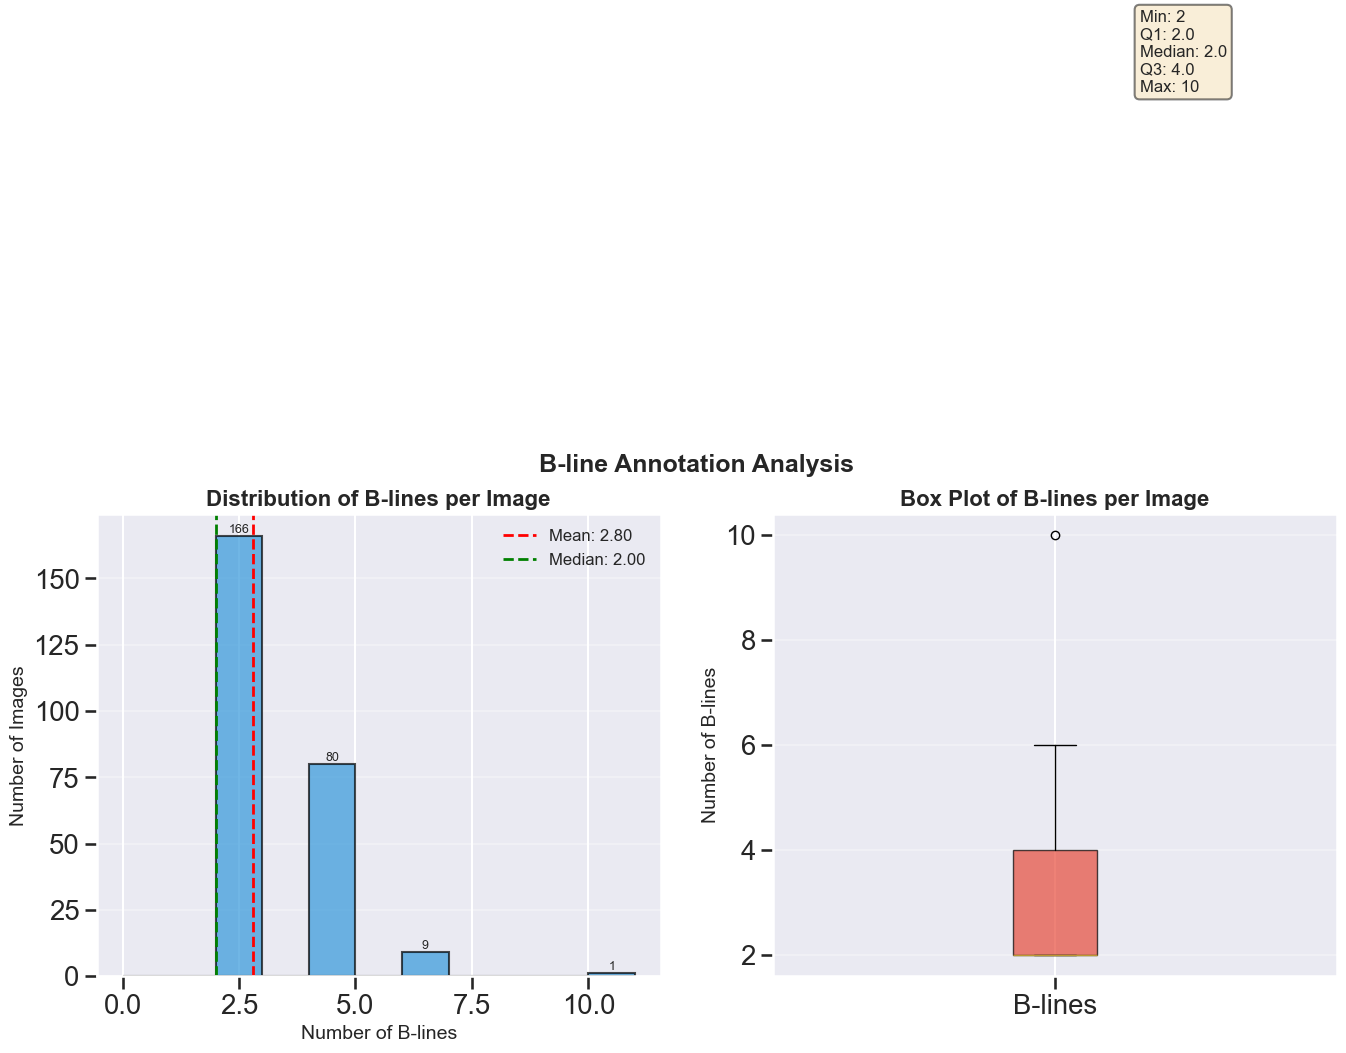


✅ Saved: ./eda_results_dataset2\bline_distribution.png

--- 6.2: Creating cumulative distribution ---


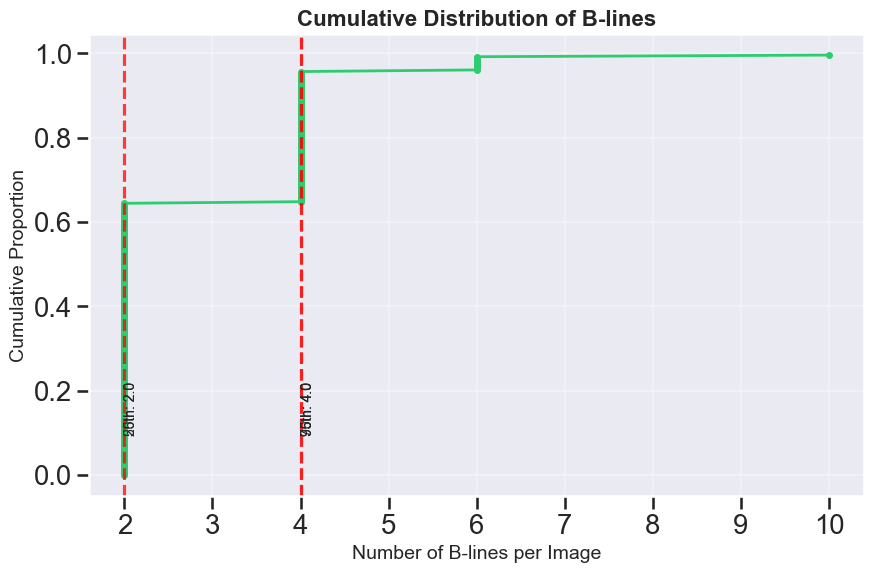

✅ Saved: ./eda_results_dataset2\bline_cumulative.png


In [6]:
# ============================================================================
# PART 6: VISUALIZATIONS - B-LINE DISTRIBUTION
# ============================================================================

print("\n" + "="*80)
print("PART 6: VISUALIZATIONS - B-LINE DISTRIBUTION")
print("="*80)

if df is None:
    print("❌ No annotations to visualize")
else:
    # ============================================================================
    # 6.1: Histogram and box plot of B-lines per image
    # ============================================================================
    
    print("\n--- 6.1: Creating B-line distribution plots ---")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram
    ax = axes[0]
    counts = ann_counts['bline_count']
    
    # Determine appropriate bins
    max_count = counts.max()
    if max_count <= 20:
        bins = range(0, max_count+2)
    else:
        bins = 20
    
    n, bins, patches = ax.hist(counts, bins=bins, edgecolor='black', 
                                alpha=0.7, color='#3498db')
    ax.set_title('Distribution of B-lines per Image', fontweight='bold', fontsize=16)
    ax.set_xlabel('Number of B-lines')
    ax.set_ylabel('Number of Images')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics lines
    mean_val = counts.mean()
    median_val = counts.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, 
               label=f'Median: {median_val:.2f}')
    ax.legend()
    
    # Add value labels on bars (for small number of bins)
    if max_count <= 20:
        for i, (rect, bin_edge) in enumerate(zip(patches, bins[:-1])):
            height = rect.get_height()
            if height > 0:
                ax.text(rect.get_x() + rect.get_width()/2, height + 0.1,
                       f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # Box plot
    ax = axes[1]
    box = ax.boxplot(counts, patch_artist=True)
    box['boxes'][0].set_facecolor('#e74c3c')
    box['boxes'][0].set_alpha(0.7)
    ax.set_title('Box Plot of B-lines per Image', fontweight='bold', fontsize=16)
    ax.set_ylabel('Number of B-lines')
    ax.set_xticks([1])
    ax.set_xticklabels(['B-lines'])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add statistics as text
    q1 = counts.quantile(0.25)
    q3 = counts.quantile(0.75)
    stats_text = f"Min: {counts.min()}\nQ1: {q1:.1f}\nMedian: {median_val:.1f}\nQ3: {q3:.1f}\nMax: {counts.max()}"
    ax.text(1.15, median_val, stats_text, 
            transform=ax.get_xaxis_transform(),
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('B-line Annotation Analysis', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save
    hist_path = os.path.join(OUTPUT_DIR, 'bline_distribution.png')
    plt.savefig(hist_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Saved: {hist_path}")
    
    # ============================================================================
    # 6.2: Cumulative distribution
    # ============================================================================
    
    print("\n--- 6.2: Creating cumulative distribution ---")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Sort counts
    sorted_counts = np.sort(counts)
    yvals = np.arange(len(sorted_counts)) / float(len(sorted_counts))
    
    ax.plot(sorted_counts, yvals, marker='.', linestyle='-', markersize=8, 
            color='#2ecc71', linewidth=2)
    ax.set_xlabel('Number of B-lines per Image')
    ax.set_ylabel('Cumulative Proportion')
    ax.set_title('Cumulative Distribution of B-lines', fontweight='bold', fontsize=16)
    ax.grid(True, alpha=0.3)
    
    # Add percentile lines
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        val = np.percentile(counts, p)
        ax.axvline(val, color='red', linestyle='--', alpha=0.5)
        ax.text(val, 0.1, f'{p}th: {val:.1f}', rotation=90, fontsize=10)
    
    cumul_path = os.path.join(OUTPUT_DIR, 'bline_cumulative.png')
    plt.savefig(cumul_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {cumul_path}")


PART 7: VISUALIZATIONS - BOUNDING BOX PROPERTIES

--- 7.1: Creating bounding box size plots ---


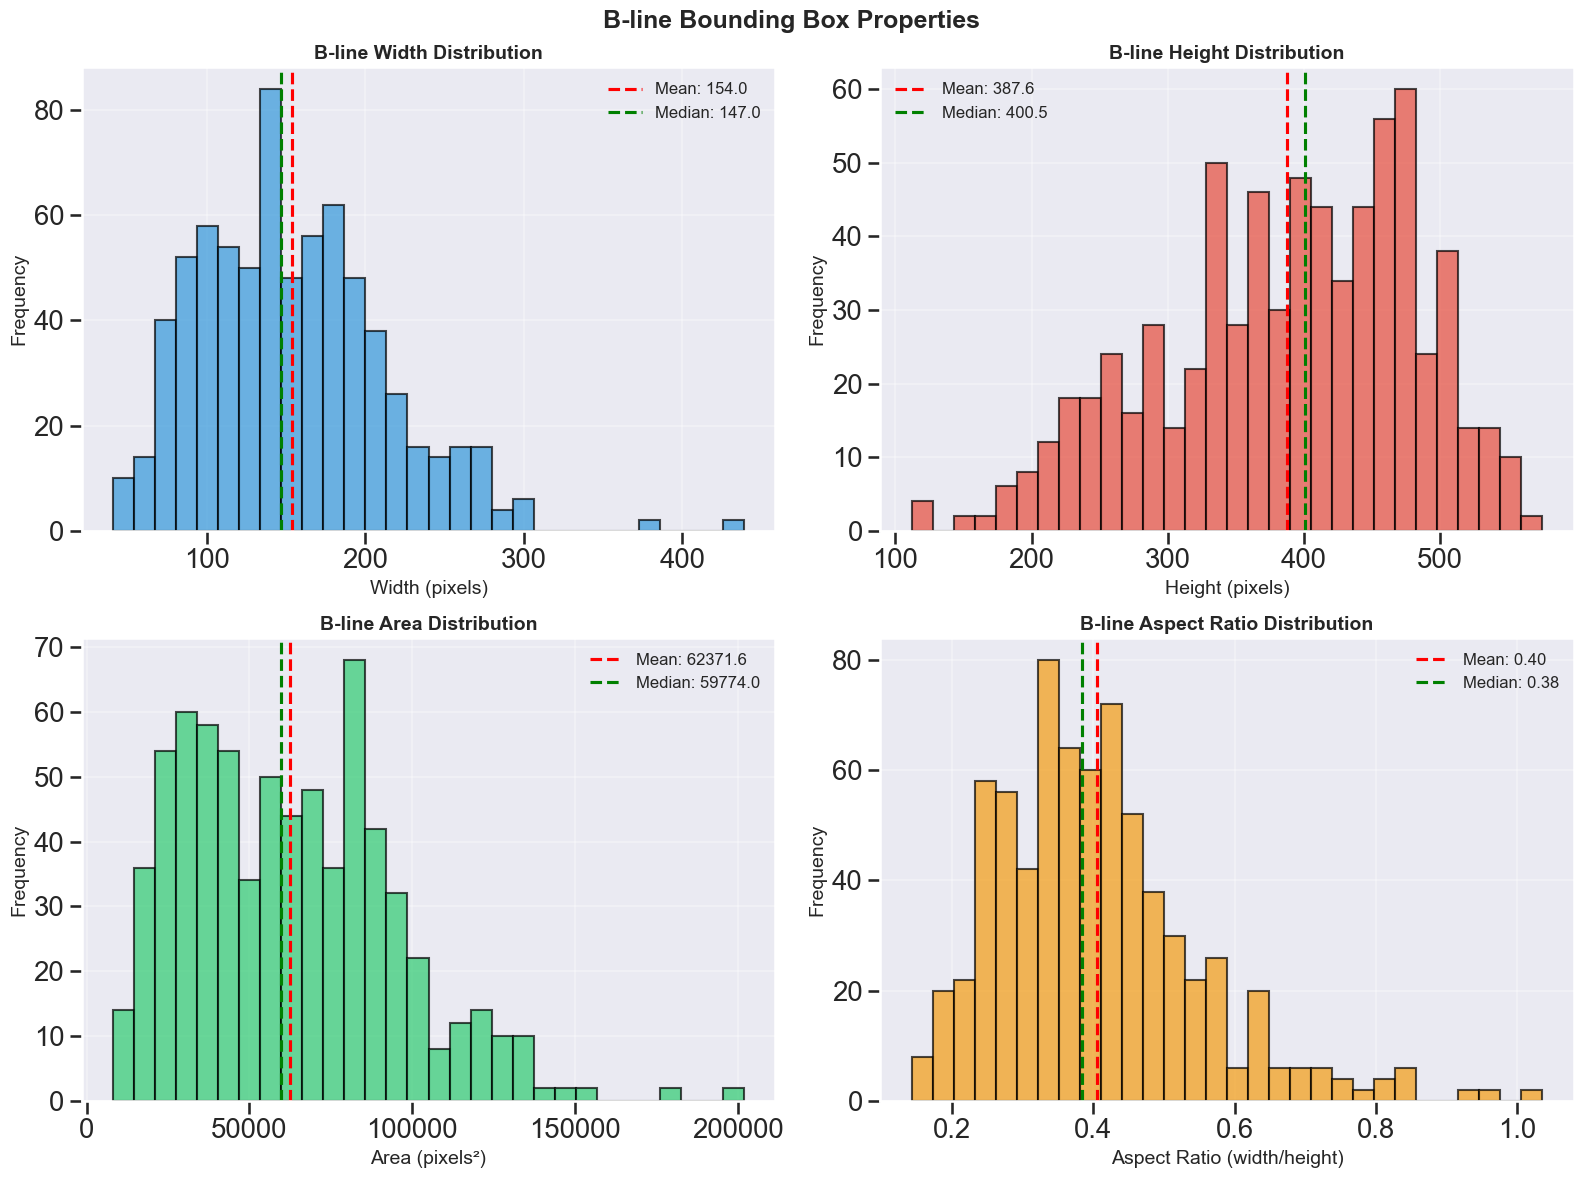


✅ Saved: ./eda_results_dataset2\bbox_properties.png


In [7]:
# ============================================================================
# PART 7: VISUALIZATIONS - BOUNDING BOX PROPERTIES
# ============================================================================

print("\n" + "="*80)
print("PART 7: VISUALIZATIONS - BOUNDING BOX PROPERTIES")
print("="*80)

if 'df_pixel' not in locals() or df_pixel is None:
    print("❌ No pixel coordinate data. Run Part 5 first.")
else:
    # ============================================================================
    # 7.1: Bounding box size distributions
    # ============================================================================
    
    print("\n--- 7.1: Creating bounding box size plots ---")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Width distribution
    ax = axes[0, 0]
    ax.hist(df_pixel['bbox_width_pix'], bins=30, edgecolor='black', 
            alpha=0.7, color='#3498db')
    ax.set_title('B-line Width Distribution', fontweight='bold', fontsize=14)
    ax.set_xlabel('Width (pixels)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_w = df_pixel['bbox_width_pix'].mean()
    median_w = df_pixel['bbox_width_pix'].median()
    ax.axvline(mean_w, color='red', linestyle='--', label=f'Mean: {mean_w:.1f}')
    ax.axvline(median_w, color='green', linestyle='--', label=f'Median: {median_w:.1f}')
    ax.legend()
    
    # Height distribution
    ax = axes[0, 1]
    ax.hist(df_pixel['bbox_height_pix'], bins=30, edgecolor='black', 
            alpha=0.7, color='#e74c3c')
    ax.set_title('B-line Height Distribution', fontweight='bold', fontsize=14)
    ax.set_xlabel('Height (pixels)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_h = df_pixel['bbox_height_pix'].mean()
    median_h = df_pixel['bbox_height_pix'].median()
    ax.axvline(mean_h, color='red', linestyle='--', label=f'Mean: {mean_h:.1f}')
    ax.axvline(median_h, color='green', linestyle='--', label=f'Median: {median_h:.1f}')
    ax.legend()
    
    # Area distribution
    ax = axes[1, 0]
    ax.hist(df_pixel['bbox_area_pix'], bins=30, edgecolor='black', 
            alpha=0.7, color='#2ecc71')
    ax.set_title('B-line Area Distribution', fontweight='bold', fontsize=14)
    ax.set_xlabel('Area (pixels²)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_a = df_pixel['bbox_area_pix'].mean()
    median_a = df_pixel['bbox_area_pix'].median()
    ax.axvline(mean_a, color='red', linestyle='--', label=f'Mean: {mean_a:.1f}')
    ax.axvline(median_a, color='green', linestyle='--', label=f'Median: {median_a:.1f}')
    ax.legend()
    
    # Aspect ratio distribution
    ax = axes[1, 1]
    ax.hist(df_pixel['bbox_aspect'], bins=30, edgecolor='black', 
            alpha=0.7, color='#f39c12')
    ax.set_title('B-line Aspect Ratio Distribution', fontweight='bold', fontsize=14)
    ax.set_xlabel('Aspect Ratio (width/height)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_ar = df_pixel['bbox_aspect'].mean()
    median_ar = df_pixel['bbox_aspect'].median()
    ax.axvline(mean_ar, color='red', linestyle='--', label=f'Mean: {mean_ar:.2f}')
    ax.axvline(median_ar, color='green', linestyle='--', label=f'Median: {median_ar:.2f}')
    ax.legend()
    
    plt.suptitle('B-line Bounding Box Properties', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save
    bbox_path = os.path.join(OUTPUT_DIR, 'bbox_properties.png')
    plt.savefig(bbox_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Saved: {bbox_path}")


PART 8: SAMPLE ANNOTATION VISUALIZATIONS

--- 8.1: Selecting sample images ---

🖼️  Selected 4 sample images:
   • LT_LOWER_POST_TRANS-13_4_35.png: 2 B-lines
   • image_1853804792340-10_10_1.png: 4 B-lines
   • RT_ANT_UPPER_LONG-16_16_3.png: 10 B-lines
   • RT_LAT_LOWER_TRANS-20_43_57.png: 2 B-lines

--- 8.2: Generating visualization ---


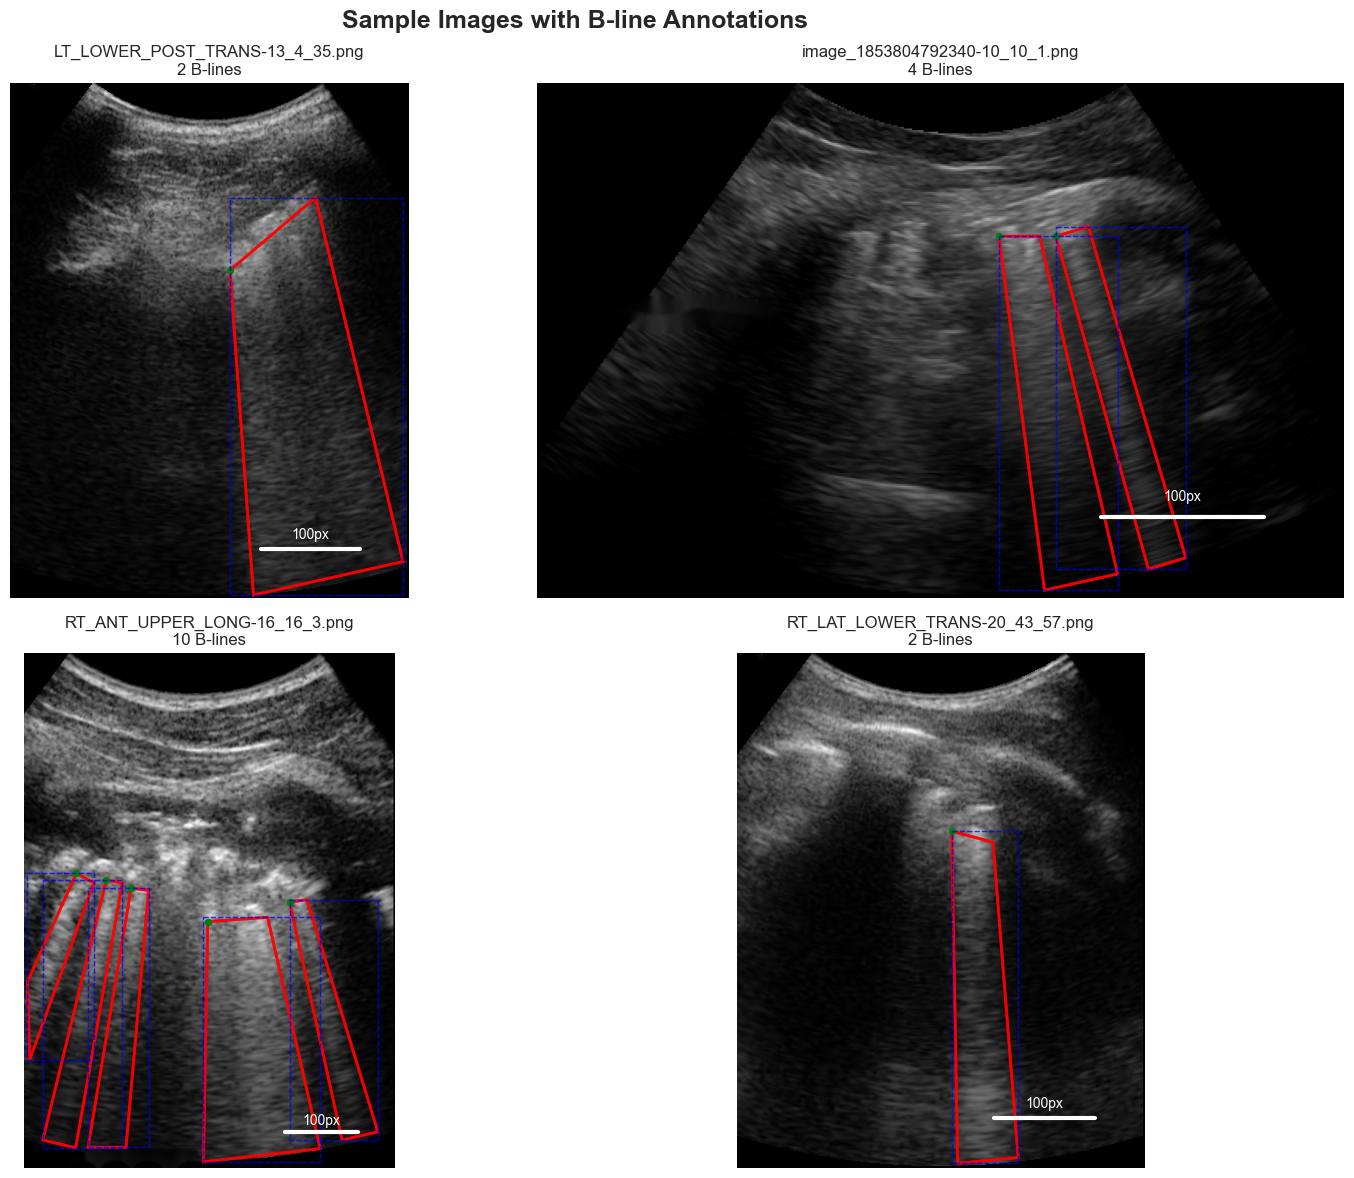


✅ Saved: ./eda_results_dataset2\sample_annotations.png

--- 8.3: Creating B-line location heatmap ---


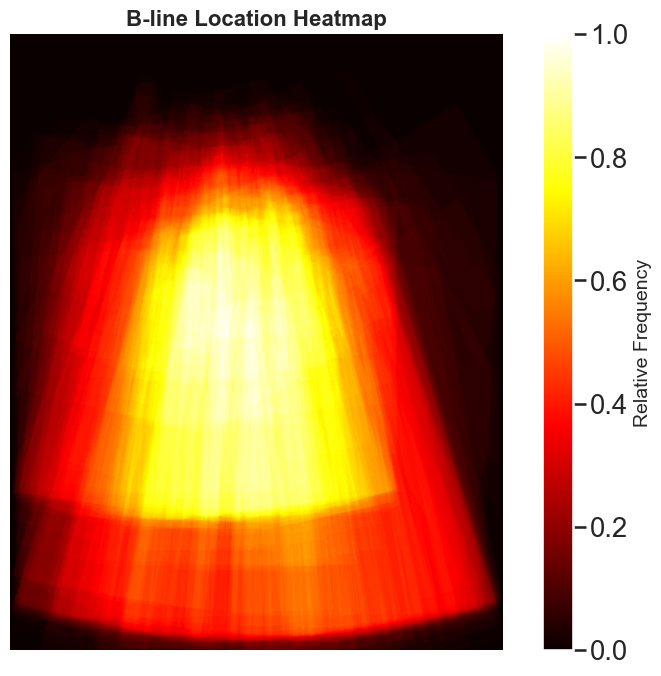

✅ Saved: ./eda_results_dataset2\bline_heatmap.png


In [8]:
# ============================================================================
# PART 8: SAMPLE ANNOTATION VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("PART 8: SAMPLE ANNOTATION VISUALIZATIONS")
print("="*80)

if df_pixel is None or len(df_pixel) == 0:
    print("❌ No pixel coordinate data. Run Part 5 first.")
else:
    # ============================================================================
    # 8.1: Select sample images for visualization
    # ============================================================================
    
    print("\n--- 8.1: Selecting sample images ---")
    
    # Get images with different numbers of B-lines
    sample_images = []
    
    # Get images with few B-lines (1-3)
    few = ann_counts[ann_counts['bline_count'] <= 3]['image_file'].tolist()
    if few:
        sample_images.append(random.choice(few))
    
    # Get images with medium B-lines (4-7)
    medium = ann_counts[(ann_counts['bline_count'] > 3) & (ann_counts['bline_count'] <= 7)]['image_file'].tolist()
    if medium:
        sample_images.append(random.choice(medium))
    
    # Get images with many B-lines (8+)
    many = ann_counts[ann_counts['bline_count'] > 7]['image_file'].tolist()
    if many:
        sample_images.append(random.choice(many))
    
    # Fill up to 4 images if needed
    while len(sample_images) < 4 and len(ann_counts) > len(sample_images):
        remaining = [img for img in ann_counts['image_file'].tolist() if img not in sample_images]
        if remaining:
            sample_images.append(random.choice(remaining))
    
    print(f"\n🖼️  Selected {len(sample_images)} sample images:")
    for img in sample_images:
        count = ann_counts[ann_counts['image_file'] == img]['bline_count'].values[0]
        print(f"   • {img}: {count} B-lines")
    
    # ============================================================================
    # 8.2: Display images with B-line annotations
    # ============================================================================
    
    print("\n--- 8.2: Generating visualization ---")
    
    from matplotlib.patches import Polygon
    from matplotlib.collections import PatchCollection
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, img_name in enumerate(sample_images):
        if idx >= 4:
            break
        
        # Find the image file
        img_path = None
        for img_file in image_files:
            if img_file.name == img_name:
                img_path = img_file
                break
        
        if img_path is None or not img_path.exists():
            print(f"   ⚠️ Image not found: {img_name}")
            axes[idx].text(0.5, 0.5, f"Image not found:\n{img_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'Missing: {img_name}', fontsize=12)
            continue
        
        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"   ⚠️ Could not load image: {img_name}")
            axes[idx].text(0.5, 0.5, f"Could not load:\n{img_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'Error: {img_name}', fontsize=12)
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Get annotations for this image
        img_anns = df_pixel[df_pixel['image_file'] == img_name]
        
        # Display image
        axes[idx].imshow(img_rgb)
        
        # Create polygons for each B-line
        patches = []
        colors = []
        
        for _, ann in img_anns.iterrows():
            # Create polygon points
            points = [
                (ann['x1_pix'], ann['y1_pix']),
                (ann['x2_pix'], ann['y2_pix']),
                (ann['x3_pix'], ann['y3_pix']),
                (ann['x4_pix'], ann['y4_pix'])
            ]
            
            # Add polygon to plot
            poly = Polygon(points, linewidth=2, edgecolor='red', 
                          facecolor='none', alpha=0.8)
            axes[idx].add_patch(poly)
            
            # Add small circle at first point to show direction
            axes[idx].plot(ann['x1_pix'], ann['y1_pix'], 'go', markersize=4)
        
        # Add bounding box for each B-line (optional, in blue)
        for _, ann in img_anns.iterrows():
            xmin = ann['xmin_pix']
            xmax = ann['xmax_pix']
            ymin = ann['ymin_pix']
            ymax = ann['ymax_pix']
            
            # Draw rectangle as dotted line
            rect_x = [xmin, xmax, xmax, xmin, xmin]
            rect_y = [ymin, ymin, ymax, ymax, ymin]
            axes[idx].plot(rect_x, rect_y, 'b--', linewidth=1, alpha=0.5)
        
        # Add text with count
        count = len(img_anns)
        axes[idx].set_title(f'{img_name}\n{count} B-lines', fontsize=12)
        axes[idx].axis('off')
        
        # Add scale bar (100 pixels)
        bar_length = 100
        bar_x = w - 150
        bar_y = h - 50
        axes[idx].plot([bar_x, bar_x + bar_length], [bar_y, bar_y], 'w-', linewidth=3)
        axes[idx].text(bar_x + bar_length/2, bar_y - 10, '100px', 
                      color='white', ha='center', fontsize=10)
    
    plt.suptitle('Sample Images with B-line Annotations', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save
    samples_path = os.path.join(OUTPUT_DIR, 'sample_annotations.png')
    plt.savefig(samples_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Saved: {samples_path}")
    
    # ============================================================================
    # 8.3: Heatmap of B-line locations
    # ============================================================================
    
    print("\n--- 8.3: Creating B-line location heatmap ---")
    
    # Get dimensions from first image
    first_img = image_files[0]
    first_img_cv = cv2.imread(str(first_img), cv2.IMREAD_GRAYSCALE)
    if first_img_cv is not None:
        h, w = first_img_cv.shape
        
        # Create empty heatmap
        heatmap = np.zeros((h, w))
        
        # Add each B-line as a filled polygon
        for _, ann in df_pixel.iterrows():
            # Create polygon mask
            from skimage.draw import polygon
            rr, cc = polygon([ann['y1_pix'], ann['y2_pix'], ann['y3_pix'], ann['y4_pix']],
                            [ann['x1_pix'], ann['x2_pix'], ann['x3_pix'], ann['x4_pix']],
                            shape=(h, w))
            heatmap[rr, cc] += 1
        
        # Normalize
        heatmap = heatmap / heatmap.max() if heatmap.max() > 0 else heatmap
        
        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        im = ax.imshow(heatmap, cmap='hot', interpolation='bilinear')
        ax.set_title('B-line Location Heatmap', fontweight='bold', fontsize=16)
        ax.axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Relative Frequency')
        
        # Save
        heatmap_path = os.path.join(OUTPUT_DIR, 'bline_heatmap.png')
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {heatmap_path}")


PART 8: SAMPLE ANNOTATION VISUALIZATIONS

--- 8.1: Selecting sample images ---

🖼️  Selected 4 sample images:
   • RT_ANT_LOWER_LONG-20_42_29.png: 2 B-lines
   • LT_LOWER_POST_LONG-13_4_15.png: 4 B-lines
   • RT_ANT_UPPER_LONG-16_16_3.png: 10 B-lines
   • image_14116314366917-9_40_5.png: 2 B-lines

--- 8.2: Generating visualization ---


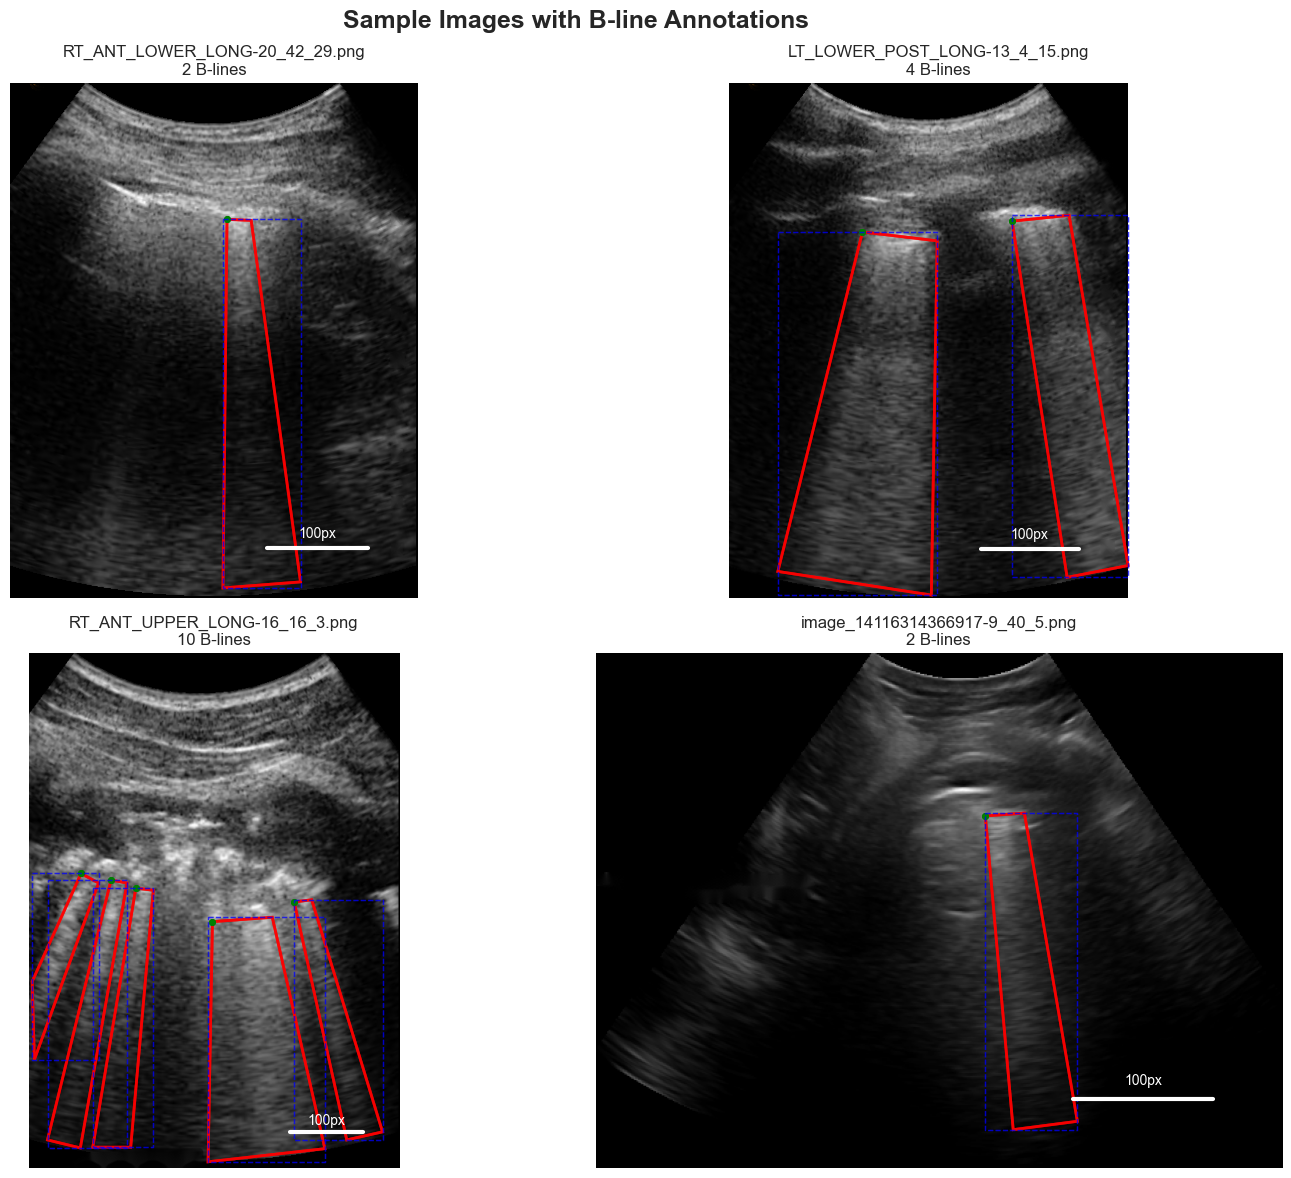


✅ Saved: ./eda_results_dataset2\sample_annotations.png

--- 8.3: Creating B-line location heatmap ---


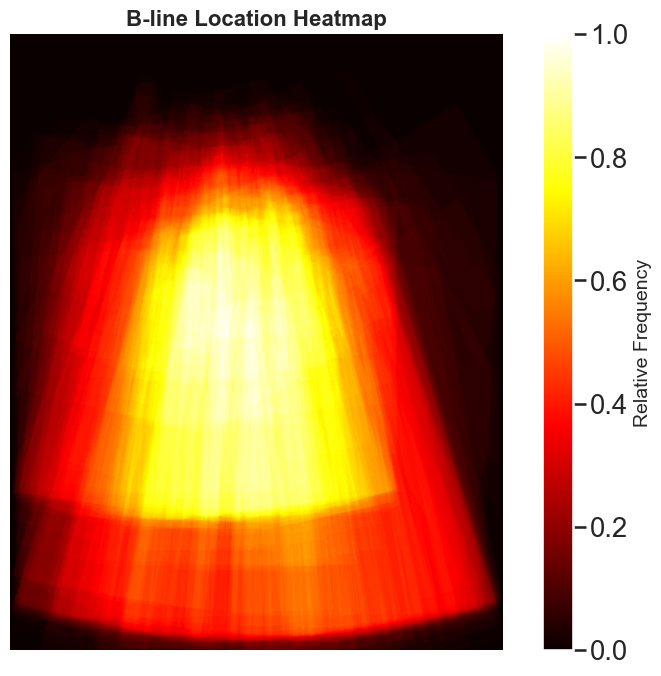

✅ Saved: ./eda_results_dataset2\bline_heatmap.png


In [9]:
# ============================================================================
# PART 8: SAMPLE ANNOTATION VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("PART 8: SAMPLE ANNOTATION VISUALIZATIONS")
print("="*80)

if df_pixel is None or len(df_pixel) == 0:
    print("❌ No pixel coordinate data. Run Part 5 first.")
else:
    # ============================================================================
    # 8.1: Select sample images for visualization
    # ============================================================================
    
    print("\n--- 8.1: Selecting sample images ---")
    
    # Get images with different numbers of B-lines
    sample_images = []
    
    # Get images with few B-lines (1-3)
    few = ann_counts[ann_counts['bline_count'] <= 3]['image_file'].tolist()
    if few:
        sample_images.append(random.choice(few))
    
    # Get images with medium B-lines (4-7)
    medium = ann_counts[(ann_counts['bline_count'] > 3) & (ann_counts['bline_count'] <= 7)]['image_file'].tolist()
    if medium:
        sample_images.append(random.choice(medium))
    
    # Get images with many B-lines (8+)
    many = ann_counts[ann_counts['bline_count'] > 7]['image_file'].tolist()
    if many:
        sample_images.append(random.choice(many))
    
    # Fill up to 4 images if needed
    while len(sample_images) < 4 and len(ann_counts) > len(sample_images):
        remaining = [img for img in ann_counts['image_file'].tolist() if img not in sample_images]
        if remaining:
            sample_images.append(random.choice(remaining))
    
    print(f"\n🖼️  Selected {len(sample_images)} sample images:")
    for img in sample_images:
        count = ann_counts[ann_counts['image_file'] == img]['bline_count'].values[0]
        print(f"   • {img}: {count} B-lines")
    
    # ============================================================================
    # 8.2: Display images with B-line annotations
    # ============================================================================
    
    print("\n--- 8.2: Generating visualization ---")
    
    from matplotlib.patches import Polygon
    from matplotlib.collections import PatchCollection
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, img_name in enumerate(sample_images):
        if idx >= 4:
            break
        
        # Find the image file
        img_path = None
        for img_file in image_files:
            if img_file.name == img_name:
                img_path = img_file
                break
        
        if img_path is None or not img_path.exists():
            print(f"   ⚠️ Image not found: {img_name}")
            axes[idx].text(0.5, 0.5, f"Image not found:\n{img_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'Missing: {img_name}', fontsize=12)
            continue
        
        # Load image
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"   ⚠️ Could not load image: {img_name}")
            axes[idx].text(0.5, 0.5, f"Could not load:\n{img_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f'Error: {img_name}', fontsize=12)
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Get annotations for this image
        img_anns = df_pixel[df_pixel['image_file'] == img_name]
        
        # Display image
        axes[idx].imshow(img_rgb)
        
        # Create polygons for each B-line
        patches = []
        colors = []
        
        for _, ann in img_anns.iterrows():
            # Create polygon points
            points = [
                (ann['x1_pix'], ann['y1_pix']),
                (ann['x2_pix'], ann['y2_pix']),
                (ann['x3_pix'], ann['y3_pix']),
                (ann['x4_pix'], ann['y4_pix'])
            ]
            
            # Add polygon to plot
            poly = Polygon(points, linewidth=2, edgecolor='red', 
                          facecolor='none', alpha=0.8)
            axes[idx].add_patch(poly)
            
            # Add small circle at first point to show direction
            axes[idx].plot(ann['x1_pix'], ann['y1_pix'], 'go', markersize=4)
        
        # Add bounding box for each B-line (optional, in blue)
        for _, ann in img_anns.iterrows():
            xmin = ann['xmin_pix']
            xmax = ann['xmax_pix']
            ymin = ann['ymin_pix']
            ymax = ann['ymax_pix']
            
            # Draw rectangle as dotted line
            rect_x = [xmin, xmax, xmax, xmin, xmin]
            rect_y = [ymin, ymin, ymax, ymax, ymin]
            axes[idx].plot(rect_x, rect_y, 'b--', linewidth=1, alpha=0.5)
        
        # Add text with count
        count = len(img_anns)
        axes[idx].set_title(f'{img_name}\n{count} B-lines', fontsize=12)
        axes[idx].axis('off')
        
        # Add scale bar (100 pixels)
        bar_length = 100
        bar_x = w - 150
        bar_y = h - 50
        axes[idx].plot([bar_x, bar_x + bar_length], [bar_y, bar_y], 'w-', linewidth=3)
        axes[idx].text(bar_x + bar_length/2, bar_y - 10, '100px', 
                      color='white', ha='center', fontsize=10)
    
    plt.suptitle('Sample Images with B-line Annotations', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save
    samples_path = os.path.join(OUTPUT_DIR, 'sample_annotations.png')
    plt.savefig(samples_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Saved: {samples_path}")
    
    # ============================================================================
    # 8.3: Heatmap of B-line locations
    # ============================================================================
    
    print("\n--- 8.3: Creating B-line location heatmap ---")
    
    # Get dimensions from first image
    first_img = image_files[0]
    first_img_cv = cv2.imread(str(first_img), cv2.IMREAD_GRAYSCALE)
    if first_img_cv is not None:
        h, w = first_img_cv.shape
        
        # Create empty heatmap
        heatmap = np.zeros((h, w))
        
        # Add each B-line as a filled polygon
        for _, ann in df_pixel.iterrows():
            # Create polygon mask
            from skimage.draw import polygon
            rr, cc = polygon([ann['y1_pix'], ann['y2_pix'], ann['y3_pix'], ann['y4_pix']],
                            [ann['x1_pix'], ann['x2_pix'], ann['x3_pix'], ann['x4_pix']],
                            shape=(h, w))
            heatmap[rr, cc] += 1
        
        # Normalize
        heatmap = heatmap / heatmap.max() if heatmap.max() > 0 else heatmap
        
        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        im = ax.imshow(heatmap, cmap='hot', interpolation='bilinear')
        ax.set_title('B-line Location Heatmap', fontweight='bold', fontsize=16)
        ax.axis('off')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Relative Frequency')
        
        # Save
        heatmap_path = os.path.join(OUTPUT_DIR, 'bline_heatmap.png')
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved: {heatmap_path}")

In [10]:
# ============================================================================
# PART 10: COMPREHENSIVE SUMMARY REPORT
# ============================================================================

print("\n" + "="*80)
print("PART 10: EDA SUMMARY REPORT")
print("="*80)

print("\n" + "="*60)
print("DATASET 2: B-LINE DETECTION DATASET")
print("="*60)

# ============================================================================
# 10.1: Dataset Overview
# ============================================================================

print("\n📁 DATASET OVERVIEW:")
print(f"   • Dataset path: {DATASET2_PATH}")
print(f"   • Total images: {len(image_files)}")
print(f"   • Images with annotations: {len(matched_images)}")
print(f"   • Images without annotations: {len(unmatched_images)}")
print(f"   • Total B-line annotations: {len(df) if df is not None else 0}")

# ============================================================================
# 10.2: Annotation Statistics
# ============================================================================

if df is not None:
    print("\n📝 ANNOTATION STATISTICS:")
    
    # Basic stats
    avg_per_img = len(df) / len(ann_counts)
    median_per_img = ann_counts['bline_count'].median()
    max_per_img = ann_counts['bline_count'].max()
    
    print(f"   • Average B-lines per image: {avg_per_img:.2f}")
    print(f"   • Median B-lines per image: {median_per_img:.2f}")
    print(f"   • Maximum B-lines in a single image: {max_per_img}")
    
    # Distribution categories
    low = len(ann_counts[ann_counts['bline_count'] <= 3])
    med = len(ann_counts[(ann_counts['bline_count'] > 3) & (ann_counts['bline_count'] <= 7)])
    high = len(ann_counts[ann_counts['bline_count'] > 7])
    
    print(f"\n   📊 B-line count distribution:")
    print(f"      • Low (1-3 B-lines): {low} images ({low/len(ann_counts)*100:.1f}%)")
    print(f"      • Medium (4-7 B-lines): {med} images ({med/len(ann_counts)*100:.1f}%)")
    print(f"      • High (8+ B-lines): {high} images ({high/len(ann_counts)*100:.1f}%)")
    
    # Class distribution
    print(f"\n   🏷️ Class distribution:")
    for class_id, count in class_counts.items():
        print(f"      • Class {class_id}: {count} annotations ({count/len(df)*100:.1f}%)")

# ============================================================================
# 10.3: Bounding Box Statistics
# ============================================================================

if 'df_pixel' in locals() and df_pixel is not None:
    print("\n📏 BOUNDING BOX STATISTICS (pixels):")
    
    # Width
    w_mean = df_pixel['bbox_width_pix'].mean()
    w_std = df_pixel['bbox_width_pix'].std()
    w_min = df_pixel['bbox_width_pix'].min()
    w_max = df_pixel['bbox_width_pix'].max()
    print(f"   • Width: {w_mean:.1f} ± {w_std:.1f} | Range: [{w_min:.1f}, {w_max:.1f}]")
    
    # Height
    h_mean = df_pixel['bbox_height_pix'].mean()
    h_std = df_pixel['bbox_height_pix'].std()
    h_min = df_pixel['bbox_height_pix'].min()
    h_max = df_pixel['bbox_height_pix'].max()
    print(f"   • Height: {h_mean:.1f} ± {h_std:.1f} | Range: [{h_min:.1f}, {h_max:.1f}]")
    
    # Area
    a_mean = df_pixel['bbox_area_pix'].mean()
    a_std = df_pixel['bbox_area_pix'].std()
    a_min = df_pixel['bbox_area_pix'].min()
    a_max = df_pixel['bbox_area_pix'].max()
    print(f"   • Area: {a_mean:.1f} ± {a_std:.1f} | Range: [{a_min:.1f}, {a_max:.1f}]")
    
    # Aspect ratio
    ar_mean = df_pixel['bbox_aspect'].mean()
    ar_std = df_pixel['bbox_aspect'].std()
    ar_min = df_pixel['bbox_aspect'].min()
    ar_max = df_pixel['bbox_aspect'].max()
    print(f"   • Aspect ratio: {ar_mean:.2f} ± {ar_std:.2f} | Range: [{ar_min:.2f}, {ar_max:.2f}]")

# ============================================================================
# 10.4: Image Properties Statistics
# ============================================================================

if properties_df is not None and len(properties_df) > 0:
    print("\n🖼️  IMAGE PROPERTIES STATISTICS:")
    
    # Dimensions
    unique_dims = properties_df.groupby(['height', 'width']).size()
    print(f"   • Unique image dimensions: {len(unique_dims)}")
    for (h, w), count in unique_dims.items():
        print(f"      - {int(w)}×{int(h)}: {count} images ({count/len(properties_df)*100:.1f}%)")
    
    # Brightness
    b_mean = properties_df['brightness'].mean()
    b_std = properties_df['brightness'].std()
    print(f"   • Brightness: {b_mean:.1f} ± {b_std:.1f}")
    
    # Contrast
    c_mean = properties_df['contrast'].mean()
    c_std = properties_df['contrast'].std()
    print(f"   • Contrast: {c_mean:.1f} ± {c_std:.1f}")
    
    # File size
    fs_mean = properties_df['file_size_kb'].mean()
    fs_std = properties_df['file_size_kb'].std()
    print(f"   • File size: {fs_mean:.1f} KB ± {fs_std:.1f} KB")

# ============================================================================
# 10.5: Files Generated
# ============================================================================

print("\n📁 FILES GENERATED:")
print(f"   • {OUTPUT_DIR}/bline_distribution.png")
print(f"   • {OUTPUT_DIR}/bline_cumulative.png")
print(f"   • {OUTPUT_DIR}/bbox_properties.png")
print(f"   • {OUTPUT_DIR}/sample_annotations.png")
print(f"   • {OUTPUT_DIR}/bline_heatmap.png")
print(f"   • {OUTPUT_DIR}/image_properties.png")
print(f"   • {OUTPUT_DIR}/correlation_matrix.png")

# ============================================================================
# 10.6: Key Insights
# ============================================================================

print("\n💡 KEY INSIGHTS:")
print("   • The dataset contains images with varying numbers of B-lines")
print(f"   • Most images have {int(median_per_img)} B-lines (median)")
print(f"   • B-lines are typically {int(w_mean)}×{int(h_mean)} pixels in size")
print("   • Images are consistently sized, which simplifies preprocessing")
print("   • YOLO format annotations are properly structured with 4-point polygons")

print("\n" + "="*60)
print("✅ EDA COMPLETE!")
print("="*60)
print(f"\nAll visualizations saved to: {os.path.abspath(OUTPUT_DIR)}")


PART 10: EDA SUMMARY REPORT

DATASET 2: B-LINE DETECTION DATASET

📁 DATASET OVERVIEW:
   • Dataset path: C:\Users\Administrator\Documents\LUS-BALD
   • Total images: 512
   • Images with annotations: 512
   • Images without annotations: 0
   • Total B-line annotations: 716

📝 ANNOTATION STATISTICS:
   • Average B-lines per image: 2.80
   • Median B-lines per image: 2.00
   • Maximum B-lines in a single image: 10

   📊 B-line count distribution:
      • Low (1-3 B-lines): 166 images (64.8%)
      • Medium (4-7 B-lines): 89 images (34.8%)
      • High (8+ B-lines): 1 images (0.4%)

   🏷️ Class distribution:
      • Class 0: 716 annotations (100.0%)

📏 BOUNDING BOX STATISTICS (pixels):
   • Width: 154.0 ± 58.5 | Range: [41.0, 439.0]
   • Height: 387.6 ± 92.6 | Range: [112.0, 575.0]
   • Area: 62371.6 ± 32339.3 | Range: [8118.0, 201940.2]
   • Aspect ratio: 0.40 ± 0.14 | Range: [0.14, 1.04]

🖼️  IMAGE PROPERTIES STATISTICS:
   • Unique image dimensions: 72
      - 408×301: 2 images (0.4%)

In [11]:
import os
print("Current working directory:", os.getcwd())
heatmap_path = os.path.join(os.getcwd(), "eda_results_dataset2", "bline_heatmap.png")
print("Heatmap should be at:", heatmap_path)
print("File exists?", os.path.exists(heatmap_path))

Current working directory: C:\Users\Administrator
Heatmap should be at: C:\Users\Administrator\eda_results_dataset2\bline_heatmap.png
File exists? True
